In [ ]:
# Cell 1 - Load Dataset Apartment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('apartments_for_rent_classified_100K.csv',
                 sep=';',
                 encoding='cp1252')

print(df.shape)
print(df.columns.tolist())
print(df.head(3))
print(df.isnull().sum())

(99492, 22)
['id', 'category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms', 'currency', 'fee', 'has_photo', 'pets_allowed', 'price', 'price_display', 'price_type', 'square_feet', 'address', 'cityname', 'state', 'latitude', 'longitude', 'source', 'time']
           id                category                            title  \
0  5668640009  housing/rent/apartment       One BR 507 & 509 Esplanade   
1  5668639818  housing/rent/apartment      Three BR 146 Lochview Drive   
2  5668639686  housing/rent/apartment  Three BR 3101 Morningside Drive   

                                                body amenities  bathrooms  \
0  This unit is located at 507 & 509 Esplanade, R...       NaN        1.0   
1  This unit is located at 146 Lochview Drive, Ne...       NaN        1.5   
2  This unit is located at 3101 Morningside Drive...       NaN        2.0   

   bedrooms currency fee  has_photo  ... price_display  price_type  \
0       1.0      USD  No  Thumbnail  ...        $2,195     M

C:\Users\asus\AppData\Local\Temp\ipykernel_28424\2983157878.py:6: DtypeWarning: Columns (0: address) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('apartments_for_rent_classified_100K.csv',


In [2]:
# Cell 2 - Drop kolom tidak relevan
drop_cols = ['id', 'category', 'title', 'body', 'amenities',
             'currency', 'price_display', 'price_type',
             'address', 'source', 'time']

df = df.drop(columns=drop_cols)

print(df.columns.tolist())
print(df.shape)

['bathrooms', 'bedrooms', 'fee', 'has_photo', 'pets_allowed', 'price', 'square_feet', 'cityname', 'state', 'latitude', 'longitude']
(99492, 11)


In [3]:
# Cell 3 - Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Drop baris yang ada missing values
df = df.dropna()

# Encode kolom kategorikal (teks)
cat_cols = ['fee', 'has_photo', 'pets_allowed', 'cityname', 'state']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Pisah fitur dan target
X = df.drop('bedrooms', axis=1)
y = df['bedrooms']

# Kurangi kelas yang datanya terlalu sedikit (opsional tapi recommended)
counts = y.value_counts()
valid_classes = counts[counts >= 10].index
df = df[y.isin(valid_classes)]
X = df.drop('bedrooms', axis=1)
y = df['bedrooms']

# Encode target
y = le.fit_transform(y)

# Normalisasi
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")
print(f"Jumlah kelas: {len(set(y))}")

Train size : (31112, 10)
Test size  : (7779, 10)
Jumlah kelas: 7


In [4]:
# Cell 4 - Algoritma Pembanding
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time

models = {
    "Logistic Regression": LogisticRegression(max_iter=200, n_jobs=-1),
    "Decision Tree"      : DecisionTreeClassifier(),
    "Random Forest"      : RandomForestClassifier(n_jobs=-1),
    "SVM"                : SVC()
}

results = {}
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    elapsed = time.time() - start
    results[name] = round(acc, 4)
    print(f"{name:25s}: {acc:.4f} | waktu: {elapsed:.2f} detik")

d:\Semester 6\SC\tugas 2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression      : 0.7728 | waktu: 1.32 detik
Decision Tree            : 0.8052 | waktu: 0.49 detik
Random Forest            : 0.8574 | waktu: 1.13 detik
SVM                      : 0.7899 | waktu: 43.25 detik


In [5]:
# Cell 5 - Neural Network
import tensorflow as tf
from tensorflow import keras

n_features = X_train.shape[1]
n_classes  = len(set(y))

model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(n_features,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(n_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

_, acc_nn = model.evaluate(X_test, y_test, verbose=0)
results["Neural Network"] = round(float(acc_nn), 4)
print(f"\nNeural Network Accuracy: {acc_nn:.4f}")

d:\Semester 6\SC\tugas 2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,975 (46.78 KB)

 Trainable params: 11,975 (46.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7288 - loss: 0.7886 - val_accuracy: 0.7757 - val_loss: 0.5877
Epoch 2/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7717 - loss: 0.6163 - val_accuracy: 0.7802 - val_loss: 0.5661
Epoch 3/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7786 - loss: 0.5888 - val_accuracy: 0.7886 - val_loss: 0.5301
Epoch 4/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7864 - loss: 0.5663 - val_accuracy: 0.7947 - val_loss: 0.5218
Epoch 5/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7861 - loss: 0.5563 - val_accuracy: 0.7982 - val_loss: 0.5115
Epoch 6/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7874 - loss: 0.5505 - val_accuracy: 0.8014 - val_loss: 0.5046
Epoch 7/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7873 - loss: 0.5451 - val_accuracy: 0.7950 - val_loss: 0.5141
Epoch 8/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7887 - loss: 0.5413 - val_accuracy: 0.

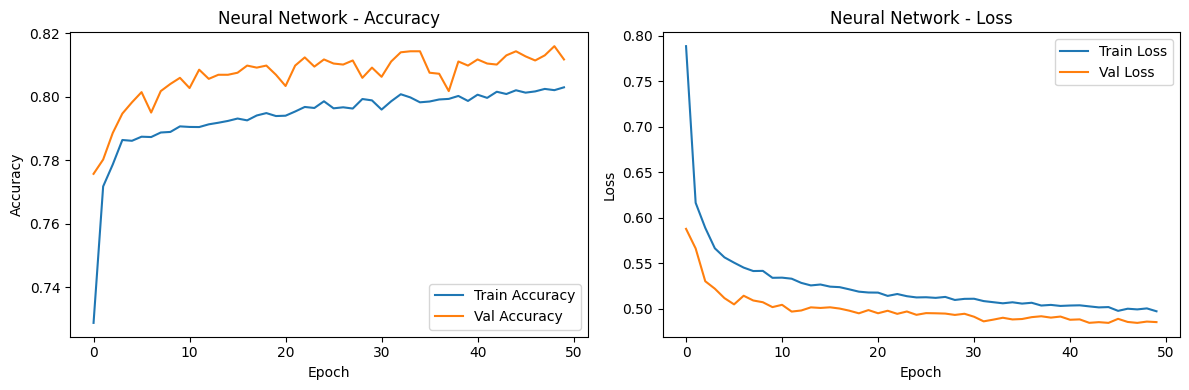

In [7]:
# Cell 6 - Plot Training History Neural Network
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Neural Network - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Neural Network - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

Model                       Accuracy
Logistic Regression           0.7728
Decision Tree                 0.8052
Random Forest                 0.8574
SVM                           0.7899
Neural Network                0.8067


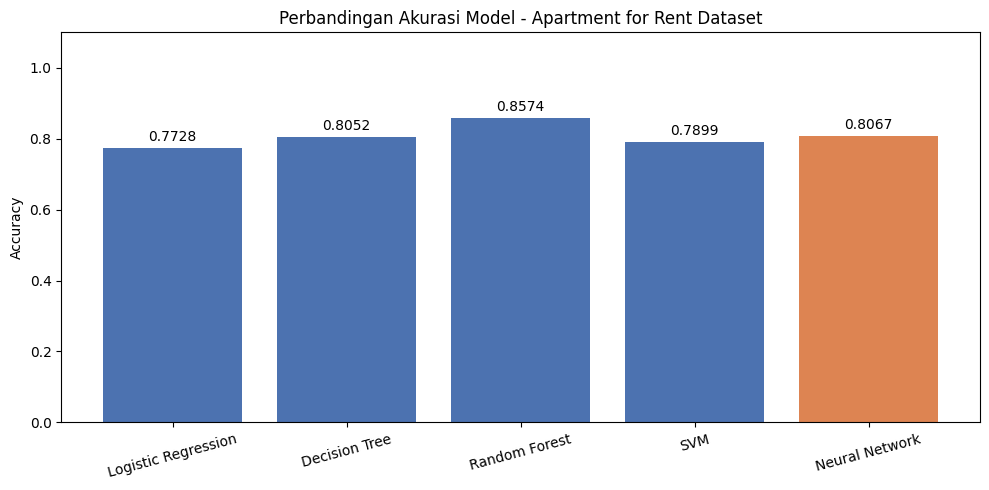

In [8]:
# Cell 7 - Perbandingan Akurasi Semua Model
print("=" * 40)
print(f"{'Model':<25} {'Accuracy':>10}")
print("=" * 40)
for name, acc in results.items():
    print(f"{name:<25} {acc:>10.4f}")
print("=" * 40)

# Bar Chart
plt.figure(figsize=(10, 5))
colors = ['#4C72B0', '#4C72B0', '#4C72B0', '#4C72B0', '#DD8452']
plt.bar(results.keys(), results.values(), color=colors)
plt.ylabel('Accuracy')
plt.title('Perbandingan Akurasi Model - Apartment for Rent Dataset')
plt.xticks(rotation=15)
plt.ylim(0, 1.1)
for i, (name, acc) in enumerate(results.items()):
    plt.text(i, acc + 0.02, f"{acc:.4f}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [1]:
import tensorflow as tf
print(tf.__version__)

2.21.0
